In [1]:
#other imports
import os
import numpy as np
import scipy as sp
import pickle
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec
from AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc

In [156]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
# decoded_variables= {'sound_category','shuffled/sound_category'}#{'choice', 'shuffled/choice'}#{'sound_category','shuffled/sound_category', 'choice', 'shuffled/choice','outcome','shuffled/outcome'}
decoded_variables= {'sound_category','shuffled/sound_category'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [157]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #testing with all datasets

# remove_indices = [8,22] #NO SOUND/CHOICE
#remove_indices = [24] #[2,8,11,22,23,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
#remove_indices = [2,7,8,20,21,22] #NO OUTCOME 11

#UPDATED (WILL NEED TO ADD DATASETS TO THIS LIST) jan 22 2025
#remove_indices = [8,22] #NO CHOICE
remove_indices = [2,8,10,22] #NO SOUND
# remove_indices = [5,10,24] #[2,8,11,22,23,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
#remove_indices = [2,7,8,20,21,22] #NO OUTCOME 11

#remove_indices =  [0,1,2,3,4,6,7,8,10,11,12,13,14,15,17,18,19,20,21,22,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
remove_indices =  [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)


# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA10-1L', '2023-03-31', 'V:')


In [158]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop

model_type = 'GLM_3nmf_passive'
results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA10-1L_2023-03-31
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/4_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/5_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/6_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/Processed

In [6]:
def save_process_multiple_datasets_output(output, filename):
    """
    Save the output of process_multiple_datasets to a file using pickle.
    
    Parameters:
    - output: The output of process_multiple_datasets
    - filename: str, the filename to save the output
    """
    with open(filename, 'wb') as file:
        pickle.dump(output, file)
    print(f"Output saved to {filename}")


def load_all_pickles_from_directory(directory):
    """
    Load all pickled files from a given directory.
    
    Parameters:
    - directory: str, the directory to search for pickled files
    
    Returns:
    - dict: A dictionary where keys are filenames (without .pkl extension) and values are the loaded data
    """
    data_dict = {}
    
    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.pkl'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'rb') as file:
                data = pickle.load(file)
                # Use the filename without the .pkl extension as the key
                key = os.path.splitext(filename)[0]
                data_dict[key] = data
                print(f"Data loaded from {filename}")
    
    return data_dict

In [7]:
# import pickle
# #save as pickled files so we can load them faster?
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre.pkl'))
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre_all_sb.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass_all_sb.pkl'))
#save_process_multiple_datasets_output(cat_results, os.path.join(save_results,'choice,' 'cat_results.pkl'))
# save_process_multiple_datasets_output(cat_results_pass, os.path.join(save_results,'choice,' 'cat_results_pass.pkl'))
# save_process_multiple_datasets_output(celltype_info, os.path.join(save_results,'choice,' 'celltype_info.pkl'))


In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [9]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [159]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
print(list(decoded_variables)[0])
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')
  

sound_category
HA10-1L_2023-03-31
HA10-1L_2023-03-31


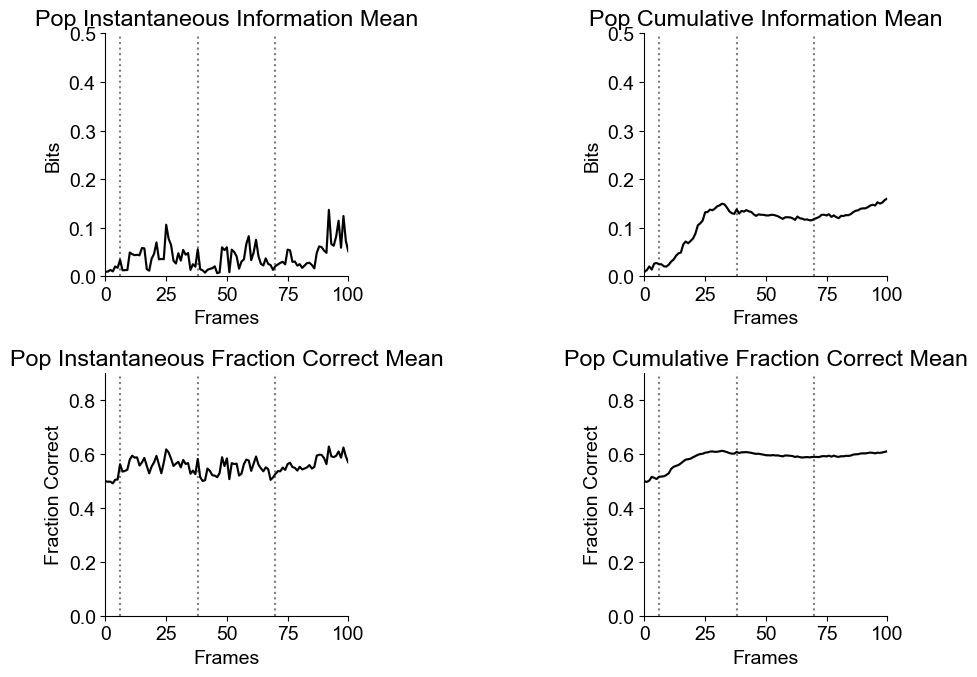

In [160]:
# Plot population decoders across datasets
current_model_type = 'pre'
results_pre_all = results_pre_all_sb
current_decoder_type = list(decoded_variables)[0] #'choice'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir= None, #f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,100),
                     ylim = [0.5, 0.5, .9, .9]) #define y limits for each subplot

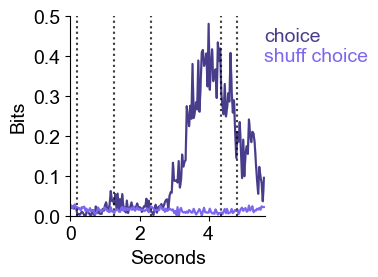

 (array([ 0.0045306 ,  0.00247826,  0.00645767,  0.01006495,  0.00706581,
        0.00091632, -0.00240692,  0.00975716,  0.00980347,  0.00651847,
        0.00201922,  0.00137373,  0.01435572,  0.00514471,  0.00087407]), array([0.01725009, 0.0192701 , 0.01312705, 0.02186423, 0.0201676 ,
       0.02301763, 0.01248174, 0.01775926, 0.00981232, 0.01305926,
       0.01917667, 0.01092001, 0.01189472, 0.01432613, 0.00453755])) 
Bonferroni corrected alpha threshold: 0.05000


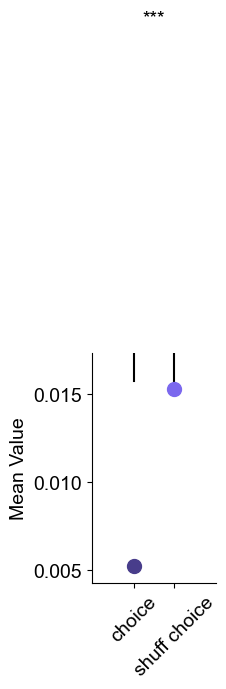

([0.00018310546875], [0.00018310546875])

In [145]:
# List of mean_results and corresponding decoder types
mean_results_list = [results_pre_all_sb, results_pre_all_sb]#[results_pre_all_sb, results_pass_all_sb]
decoder_types = ['choice','shuffled/choice'] ##['sound_category','sound_category'] #['photostim','photostim'] #['outcome', 'shuffled/outcome']

# Plot population decoders across datasets
current_model_type = 'test'#'pre' or passive
data_type = 'information'# 'fraction_correct' or 'information'
if data_type == 'information':
    ylabel = 'Bits'
    ylimss = (0.0,.5)
else:
    ylabel = 'Fraction Correct'
    ylimss = (0.45,.8)
current_decoder_type = decoder_types[0]
save_dir_contexts = f'{plotter.save_results}/{current_model_type}_instantaneous_{data_type}_{current_decoder_type}'
# results_pre_all = results_pre_all_sb 

labels = ['choice','shuff choice'] #['Active', 'Passive']
colors_used = ['darkslateblue','mediumslateblue'] #['darkslateblue','mediumslateblue']# ['mediumvioletred','hotpink']#['steelblue','lightskyblue'] #['saddlebrown','darkorange'] #['darkslateblue','mediumslateblue'] #colors for the bar plot     
frames_used = np.arange(7,22) #frames to plot in the bar/scatter plot (7,22)
os.makedirs(save_dir_contexts , exist_ok=True)


# Plot the selected metric and get concatenated means and SEMs
concatenated_means, concatenated_sems = plotter.plot_selected_metric_with_sem(mean_results_list, decoder_types, 
                                                                      metric=f'pop_instantaneous_{data_type}_mean', 
                                                                      title= None, 
                                                                      xlabel='Seconds', 
                                                                      ylabel= ylabel, #'SC Metric 1 Value',
                                                                      ylim = ylimss, #(0.01,.03)
                                                                      xlim = (0,169), #in terms of frames (30 frames = 1 second)
                                                                    save_dir=None,#save_dir_contexts,
                                                                    labels = labels,
                                                                    colors = colors_used)


# create bar or scatter plot of mean values at specific range of values
plotter.simple_plot_wrapper(labels, concatenated_means, concatenated_sems,plot_type = 'scatter', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = None)


In [10]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

In [11]:
def analyze_peaks_by_celltype_test( mean_results_all, shuffled_structure,method ='range_threshold', decoder_type='sound_category', start_frame=14, end_frame=None, significance_percentile=95, threshold =None):
    """Analyze peak responses separated by cell type and flag significantly informative neurons.
        Parameters:
    - data: dict, data for different cell types
    - method: str, method to calculate significance ('shuffled_peak', 'threshold_peak', 'range_threshold')
    - threshold: float, threshold value for 'threshold_peak' and 'range_threshold' methods
    - range_start: int, start of the range for 'range_threshold' method
    - range_end: int, end of the range for 'range_threshold' method
    
    Returns:
    - results: dict, results of the analysis
    """
    peaks_by_celltype = {
        dataset: {
            celltype: {
                'sc': {},
                'pop': {}
            } for celltype in mean_results_all[dataset]['neuron_groups']
        } for dataset in mean_results_all
    }
    # Single cell metrics
    sc_metrics = ['sc_instantaneous_information_mean','sc_cumulative_information_mean','sc_instantaneous_fraction_correct_mean','sc_cumulative_fraction_correct_mean']
    
    for dataset in mean_results_all:
        celltype_array = mean_results_all[dataset]['celltype_array']
        # Get indices for each cell type
        celltype_indices = {
            'pyr': np.where(celltype_array == 0)[0],
            'som': np.where(celltype_array == 1)[0],
            'pv': np.where(celltype_array == 2)[0]
        }
        # Process single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                if end_frame is None:
                    end_frame = len(data)
                # Retrieve shuffled data for comparison
                shuffled_data = shuffled_structure [dataset] #mean_results_all[dataset][f'shuffled/{decoder_type}'][metric]
                for celltype, indices in celltype_indices.items():
                    peaks = []
                    peak_frames = []
                    significant_neurons = []  # Track significant neurons for this metric
                    for idx in indices:
                        neuron_data = data[start_frame:end_frame, idx]
                        peak_val = np.max(neuron_data)
                        peak_frame = np.argmax(neuron_data) + start_frame
                        
                        peaks.append(peak_val)
                        peak_frames.append(peak_frame)
                        # Flag the neuron as significant if the peak value exceeds the 95th percentile
                        if method == 'shuffled_peak':#threshold is None:
                            # Compute the peak value for the shuffled distribution
                            shuffled_peak = shuffled_data[peak_frame, idx, :]
                            # Compute the 95th percentile of the shuffled peak values
                            shuffled_95th_percentile = np.percentile(shuffled_peak, significance_percentile)
                            is_significant = peak_val > shuffled_95th_percentile
                            significant_neurons.append(is_significant)
                        elif method == 'range_threshold':
                            print('range_threshold')
                            is_significant = np.any(neuron_data > threshold)
                            significant_neurons.append(is_significant)
                        elif method == 'threshold_peak':
                            print('threshold_peak')
                            is_significant = peak_val > threshold
                            significant_neurons.append(is_significant)
                                
                                

range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_threshold
range_th

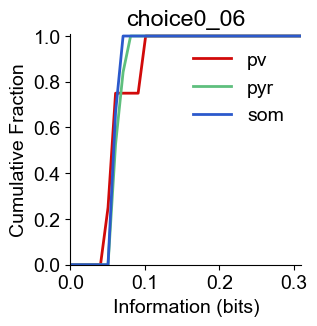

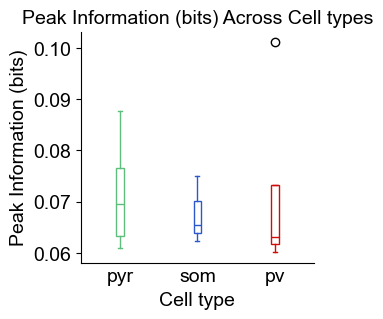

In [147]:
#DECIDE WHETHER OR NOT TO USE END FRAME
current_model_type = 'test'
current_decoder_type = 'choice' #'sound_category' #'photostim' #'outcome'
results_pre_all = results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold =  0.06 #use threshold OR percentile to decide signficant neurons
method = 'range_threshold'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined'
metric_to_plot = 'sc_instantaneous_information_mean'

# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
save_path = f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path , exist_ok=True)

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 5, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!

cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
if "shuffled" in current_decoder_type:
    current_decoder_type = current_decoder_type.replace('/', '_') #replace / with _
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title=f'{current_decoder_type}{threshold_str}',
                                xlabel = 'Information (bits)',
                                xval=.3,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.svg')

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.png'
)

#heatmap across datasets
#plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')


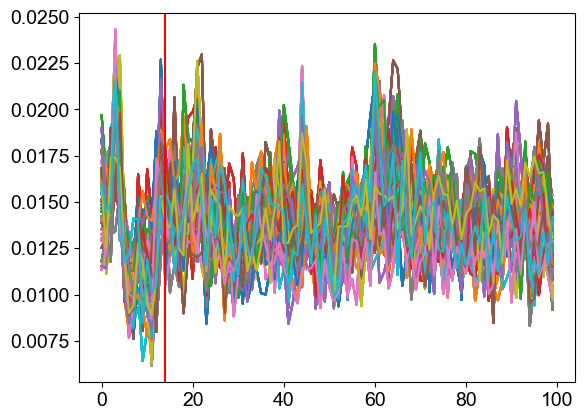

In [162]:
import matplotlib.pyplot as plt 
plt.plot(np.mean(shuffled_structure_pass['HA10-1L_2023-03-31'][0:100,:,:], axis = 1))
plt.axvline(x = 14, color = 'r')


HA10-1L_2023-03-31
0.03054819016405512


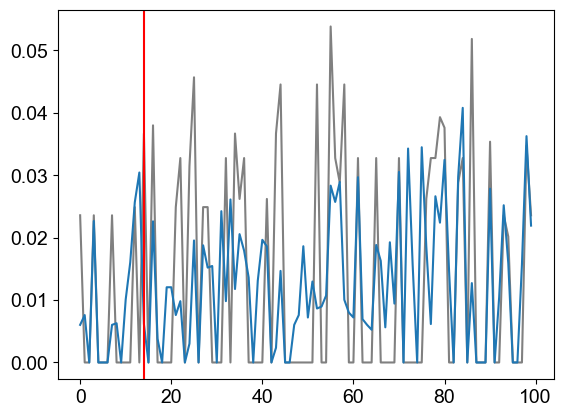

In [182]:
example_neuron =  100
metric_to_plot = 'sc_instantaneous_information'
mt = 'pass' # or pre

shuffled_structure = data_handler_pass.create_shuffled_distribution_structure(decoder_type = 'sound_category', metric = metric_to_plot)
shuffled_dist = shuffled_structure['HA10-1L_2023-03-31'][0:100,example_neuron,:] #becomes frames x shuffles
thr = np.percentile(shuffled_dist, 95, axis=1) # axis = 1 gives 86 values (frames?), axis = 0 gives 500 values (shuffles?)
print(np.mean(thr))
plt.plot(np.mean(shuffled_dist, axis = 1), color = 'gray')
plt.plot(results_pass_all_sb['HA10-1L_2023-03-31']['sound_category'][f'{metric_to_plot}_mean'][0:100,example_neuron]) #frames x cells
plt.axvline(x = 14, color = 'r')

In [178]:
results_pre['HA10-1L_2023-03-31']['sound_category'][0]['sc_instantaneous_information_mean'].shape

(169, 396)

In [168]:
np.where((results_pass_all_sb['HA10-1L_2023-03-31']['sound_category']['sc_instantaneous_information_mean'][14:100,:]>0.08).sum(axis=0)) #number of significant neurons

(array([  2,   9,  16,  21,  34,  68, 127, 254, 270, 276, 282, 319, 328,
        346, 358, 382], dtype=int64),)

In [147]:
celltype_ex = 'som'
print(np.where(peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['significant_neurons']))
print((peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['peak_values'][np.where(peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['significant_neurons'])]))   

(array([4], dtype=int64),)
[0.06710303]


In [46]:
analysis_dec.metrics

{'sc': ['sc_instantaneous_information_mean',
  'sc_cumulative_information_mean',
  'sc_instantaneous_fraction_correct_mean',
  'sc_cumulative_fraction_correct_mean'],
 'pop': ['pop_instantaneous_information_mean',
  'pop_cumulative_information_mean',
  'pop_instantaneous_fraction_correct_mean',
  'pop_cumulative_fraction_correct_mean']}

In [70]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None,method = 'shuffled_peaks', save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure,method, decoder_type, start_frame, end_frame,metric ,significance_percentile, threshold = threshold)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    # if threshold is not None:
    #     significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=f'{save_path}_hist.svg') 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons,save_path=f'{save_path}_heatmap.svg') #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=f'{save_path}.png')

    return significant_neurons_data, significance_struc, significant_neurons

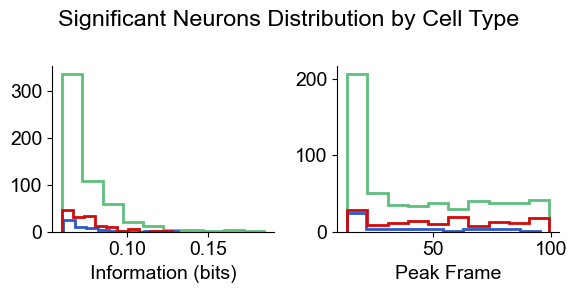

<Figure size 640x480 with 0 Axes>

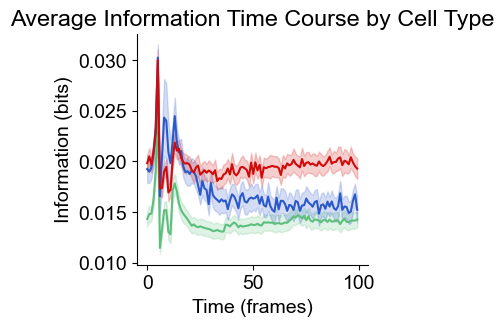

Sig neurons total 702


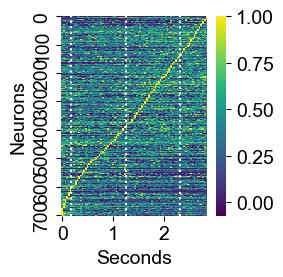

Total significant neurons!! 27


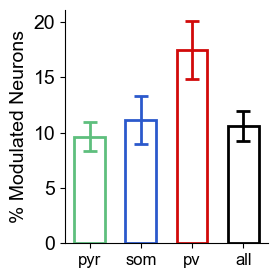

Significantly Modulated Neurons (% ± SEM):
pyr: 9.63 ± 1.33%
som: 11.14 ± 2.17%
pv: 17.45 ± 2.61%
all: 10.61 ± 1.37%


In [71]:
# Call the visualization function
threshold = 0.06
current_decoder_type = 'photostim' #'shuffled/photostim' #'shuffled/outcome'
significant_neurons_data, sig_struct, sig_neurons = visualize_single_neuron_analysis(
    results_dict=results_pre_all_sb,
    shuffled_structure = shuffled_structure,
    method = 'threshold_peak', #threshold_peak', 'range_threshold'
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 100,                    # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= None #f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [137]:
print(significant_neurons_data['HA11-1R_2023-05-05']['pyr'])
sig_neurons['HA11-1R_2023-05-05']

KeyError: 'HA11-1R_2023-05-05'

In [136]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])

# Prepare data for saving
matlab_data = {}
for dataset, celltypes in significant_neurons_data.items():
    print(dataset)
    sanitized_dataset = sanitize_field_name(dataset)
    matlab_data[sanitized_dataset] = {}
    for celltype, indices in celltypes.items():
        sanitized_celltype = sanitize_field_name(celltype)
        
        if indices is None:
            peaks = [peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values'][index] for index in indices]
            # Add one to each index for MATLAB indexing
            indices = [index + 1 for index in indices]
            matlab_data[sanitized_dataset][sanitized_celltype] = {
                'indices': indices,
                'peaks': peaks
            }
# # Prepare data for saving
# matlab_data = {}
# for dataset, celltypes in significant_neurons_data.items():
#     sanitized_dataset = sanitize_field_name(dataset)
#     matlab_data[sanitized_dataset] = {}
#     for celltype, data in celltypes.items():
#         sanitized_celltype = sanitize_field_name(celltype)
#         matlab_data[sanitized_dataset][sanitized_celltype] = [index + 1 for index in indices]  # Save indices of significant neurons 

# Save significant neurons data to a .mat file
mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, matlab_data)
print(f'Significant neurons data saved to {mat_file_path}')

pyr
som
pv
all
Significant neurons data saved to V:/Connie/results/glm_decoding/prelim/test14sound_category/significant_neurons_data.mat


In [133]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])
# Print the number of significant neurons per cell type and prepare data for saving
significant_neurons_data = {}
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')
        sanitized_cell_type = sanitize_field_name(cell_type)
        significant_neurons_data[sanitized_cell_type] = {
            'num_significant_neurons': num_significant_neurons,
            'peaks': np.array(data['peaks'])
        }
        print(significant_neurons_data[sanitized_cell_type]['peaks'])

mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, significant_neurons_data)

Cell type: pyr, Number of significant neurons: 521
[0.06093128 0.06288881 0.0602526  0.06305552 0.06261113 0.06077094
 0.07970873 0.07410653 0.06040351 0.10620771 0.10361535 0.0639753
 0.09420181 0.07870833 0.09098404 0.06936493 0.07426267 0.09156709
 0.0780108  0.06940708 0.07359389 0.0628773  0.06111851 0.06154277
 0.08977398 0.24531104 0.10648276 0.0968074  0.0612636  0.08091833
 0.06429535 0.1909286  0.06744243 0.06720493 0.07376014 0.06353274
 0.07911372 0.06161994 0.07491103 0.06001709 0.06331738 0.06409033
 0.06304625 0.11242805 0.08927624 0.06207144 0.06245788 0.06312303
 0.06979827 0.0762244  0.27840908 0.34775523 0.10144604 0.07176455
 0.06750405 0.06289369 0.06267357 0.08986289 0.0835114  0.12695251
 0.07013271 0.12331507 0.06276232 0.06318782 0.07229682 0.14554729
 0.08805272 0.08702839 0.16766645 0.06894762 0.09499151 0.07068461
 0.06996251 0.06081113 0.06187135 0.06800253 0.06201456 0.06705307
 0.06626261 0.13169007 0.0766899  0.22183663 0.11579995 0.14277114
 0.07487704 